# Para este ejercicio es necesario recordar la forma en que se debe evaluar un prompt. 
La siguiente imagen es tomada del curso oficial:
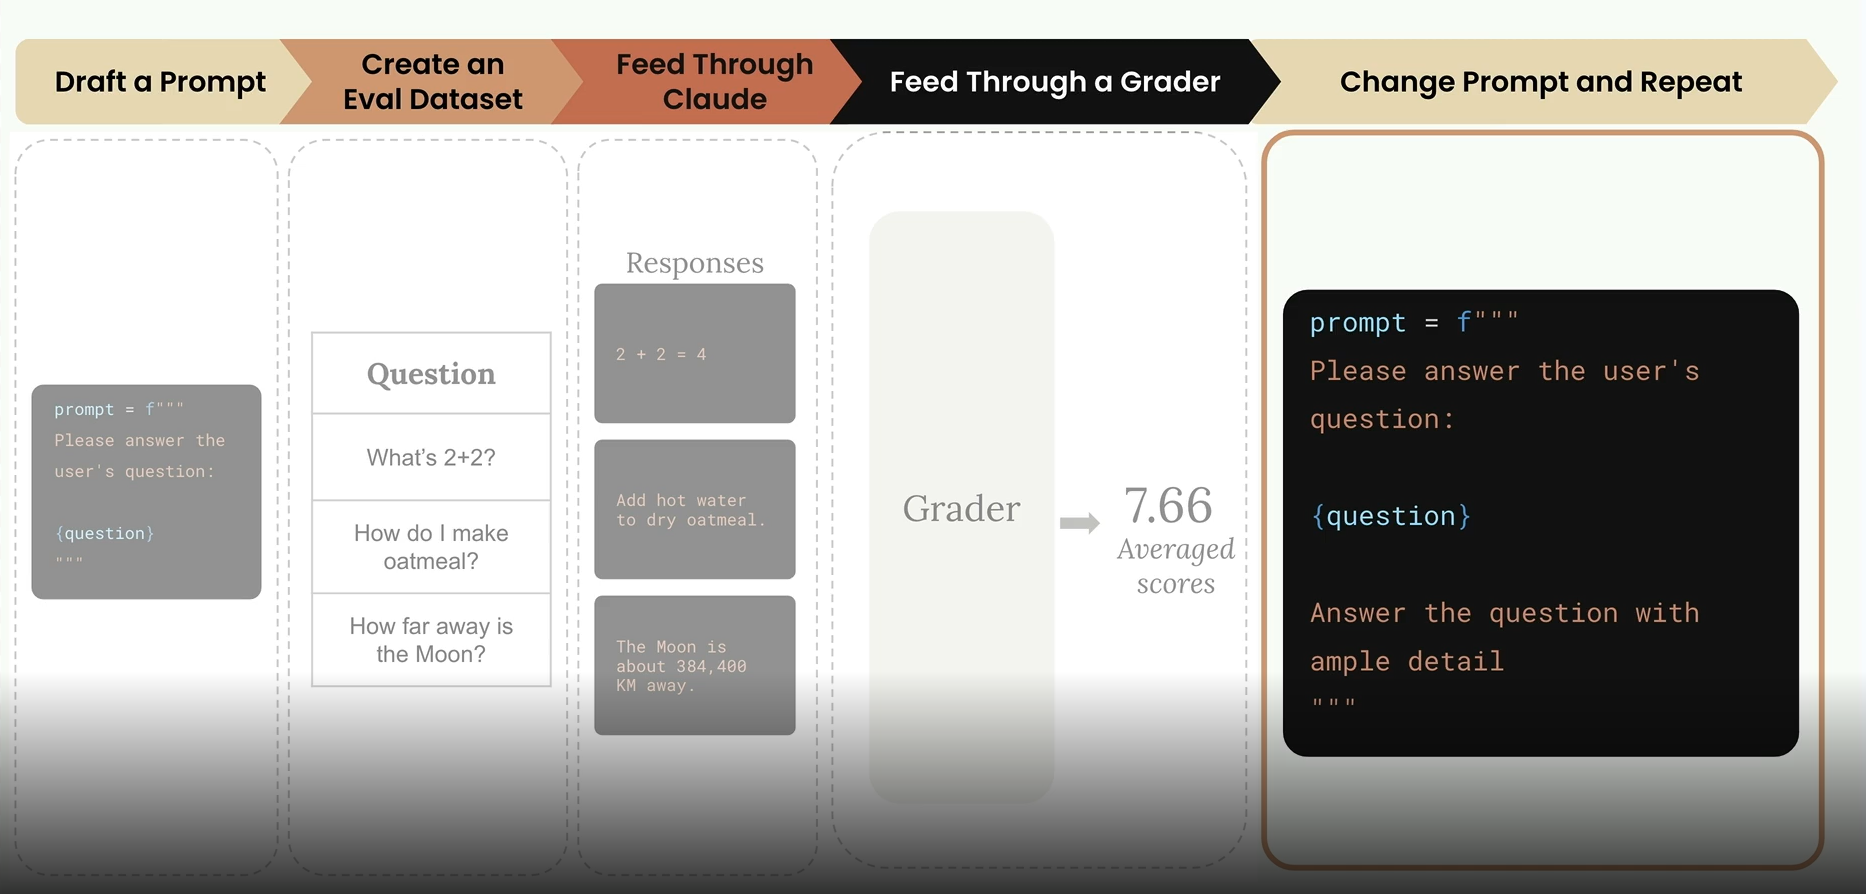

# El objetivo será:
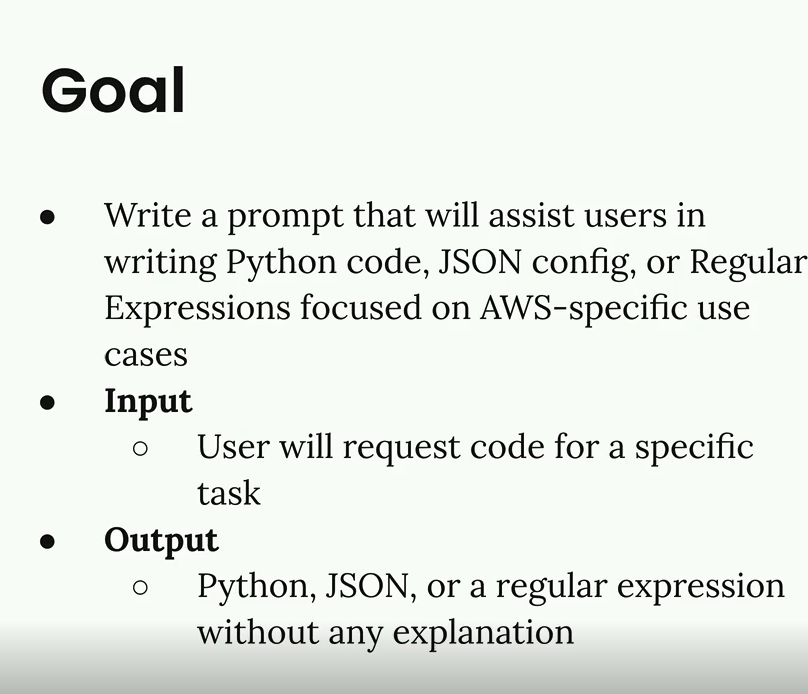



# Iniciamos por diseñar el prompt inicial (prompt V1):

prompt = f"""
Please provide a solution to the following task:

{task}

Respond with only the code (Python, JSON, or Regular Expression) with no explanations, comments, or markdown formatting.
"""

# Segundo paso será armar el dataset de evaluación del prompt V1:
test_dataset = [
    # Python tasks
    {"task": "Write a Python script to list all S3 buckets in my AWS account"},
    {"task": "Write a Python function to upload a file to an S3 bucket"},
    {"task": "Write a Python script to start an EC2 instance by instance ID"},
    {"task": "Write a Python function to get all running EC2 instances"},
    {"task": "Write a Python script to send a message to an SQS queue"},
    
    # JSON tasks
    {"task": "Write a JSON IAM policy that allows read-only access to S3"},
    {"task": "Write a JSON CloudFormation resource to create an S3 bucket"},
    {"task": "Write a JSON EventBridge rule to trigger a Lambda every 5 minutes"},
    {"task": "Write a JSON IAM policy that allows Lambda to write to DynamoDB"},
    {"task": "Write a JSON API Gateway resource definition for a GET endpoint"},
    
    # Regex tasks
    {"task": "Write a regular expression to validate an AWS S3 bucket name"},
    {"task": "Write a regular expression to match an AWS ARN"},
    {"task": "Write a regular expression to validate an AWS region name"},
    {"task": "Write a regular expression to match an EC2 instance ID"},
    {"task": "Write a regular expression to validate an AWS account ID"},
]

In [1]:
# Install dependencies
%pip install anthropic python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Load Variables
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
# Create an API Client
from anthropic import Anthropic
import os

client = Anthropic()
model = "claude-sonnet-4-5"

In [4]:
# Funciones auxiliares
from os import system

def add_user_message(messages, user_input):
    messages.append({"role": "user", "content": user_input})

def add_assistant_message(messages, answer):
    messages.append({"role": "assistant", "content": answer})

def chat(messages, system=None, temperature=1.0, stop_sequences=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    if system:
        params["system"] = system
    if stop_sequences:
        params["stop_sequences"] = stop_sequences

    response = client.messages.create(**params)
    return response.content[0].text

In [5]:
import json

def generate_dataset():
    prompt = """
Generate an evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects, each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
{
    "task": "Description of task",
},
...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a single regex
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```json")
    text=chat(messages, temperature=0.7, stop_sequences=["```"])
    return json.loads(text)

In [7]:
dataset = generate_dataset()
with open("dataset.json", "w") as f:
    json.dump(dataset, f, indent=2)
#print(json.dumps(dataset, indent=2))